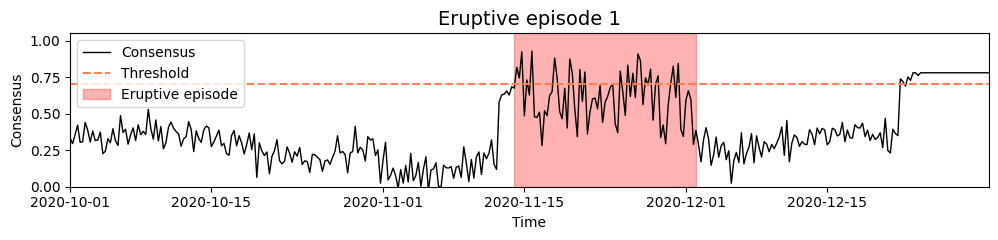

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

# Update time range to match the new eruption period
start_date = datetime(2020, 10, 1)  # A few days before eruption
end_date = datetime(2020, 12, 31)     # A few days after eruption
dates = pd.date_range(start=start_date, end=end_date, freq='6h')

# Generate synthetic data similar to the image
np.random.seed(42)  # For reproducibility
n = len(dates)

# Generate consensus data with similar pattern
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise
    if i < n/3:
        consensus[i] = base + 0.1 * np.sin(i/20) + 0.07 * np.random.randn()
    elif i < 2*n/3:
        consensus[i] = base + 0.2 * np.sin(i/30) + 0.08 * np.random.randn()
    else:
        if i > 0.9*n:  # Sharp increase at the end
            consensus[i] = min(0.78, base + 0.4 + (i - 0.9*n)/(0.1*n) * 0.5 + 0.05 * np.random.randn())
        else:
            consensus[i] = base + 0.05 * np.sin(i/15) + 0.07 * np.random.randn()

# Create the spike for the eruption period
eruption_start_idx = np.where(dates >= datetime(2020, 11, 14))[0][0]
eruption_end_idx = np.where(dates >= datetime(2020, 12, 1, 23, 59))[0][0]

# Make the consensus value rise above threshold during eruption
for i in range(eruption_start_idx-6, eruption_start_idx):
    # Gradual increase before eruption
    consensus[i] = base + 0.4 * (i - (eruption_start_idx-24)) / 24 + 0.05 * np.random.randn()

for i in range(eruption_start_idx, eruption_end_idx):
    # High values during eruption
    consensus[i] = 0.6 + 0.15 * np.random.randn()

# Set the threshold
threshold = 0.7

# Create the plot
plt.figure(figsize=(10, 2.5))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='Threshold')

# Highlight eruptive episode - updated dates
eruption_start = datetime(2020, 11, 14)
eruption_end = datetime(2020, 12, 1, 23, 59)
eruption_duration = eruption_end - eruption_start
plt.axvspan(eruption_start, eruption_end, alpha=0.3, color='red', label='Eruptive episode')

# Add annotations
hours_duration = eruption_duration.total_seconds() / 3600
# plt.text(eruption_end - timedelta(hours=12), 0.93, f'~{int(hours_duration)} hr', ha='center')
# plt.annotate('Eruptive episode 1', xy=(eruption_start + timedelta(hours=12), 0.95), 
#              ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
plt.title('Eruptive episode 1', fontsize=14)

# Format the dates on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=0)

# Add a grid and legend
plt.grid(False)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

C:\Users\Anto\AppData\Local\Temp\ipykernel_32652\466028146.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(start=start_date, end=end_date, freq='24H')  # Daily frequency


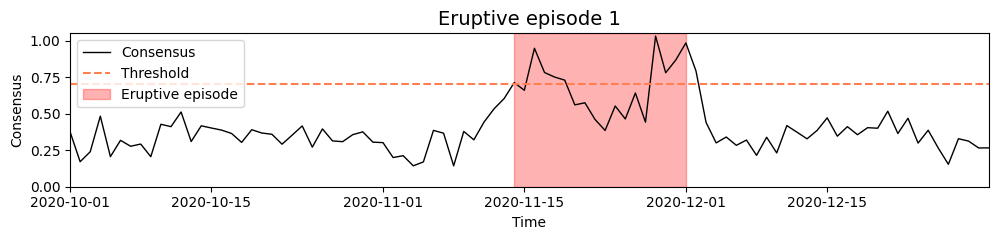

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

# Update time range according to new specifications
start_date = datetime(2020, 10, 1)   # Start of data
end_date = datetime(2020, 12, 31)    # End of data
dates = pd.date_range(start=start_date, end=end_date, freq='24H')  # Daily frequency

# Generate synthetic data similar to the image
np.random.seed(64)  # For reproducibility
n = len(dates)

# Generate consensus data with similar pattern
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise
    consensus[i] = base + 0.1 * np.sin(i/10) + 0.07 * np.random.randn()

# Find indices for eruption period
eruption_start_idx = np.where(dates >= datetime(2020, 11, 14))[0][0]
eruption_end_idx = np.where(dates >= datetime(2020, 12, 2))[0][0]  # Day after eruption ends

# Make the consensus value rise before first eruption
pre_eruption_rise_days = 5
for i in range(eruption_start_idx-pre_eruption_rise_days, eruption_start_idx):
    factor = (i - (eruption_start_idx-pre_eruption_rise_days)) / pre_eruption_rise_days
    consensus[i] = base + 0.3 * factor + 0.05 * np.random.randn()

# High values during eruption
for i in range(eruption_start_idx, eruption_end_idx):
    # Add some variability during the long eruption period
    if i - eruption_start_idx < 5:
        # Initial peak
        consensus[i] = 0.8 + 0.1 * np.random.randn()
    elif i - eruption_start_idx > (eruption_end_idx - eruption_start_idx) - 5:
        # Final peak before ending
        consensus[i] = 0.85 + 0.1 * np.random.randn()
    else:
        # Sustained but variable activity
        consensus[i] = 0.6 + 0.15 * np.sin((i - eruption_start_idx)/2) + 0.08 * np.random.randn()

# Gradual decrease after eruption for 3 days
post_eruption_days = 7
for i in range(eruption_end_idx, min(eruption_end_idx+post_eruption_days, len(consensus))):
    decay_factor = 1 - ((i - eruption_end_idx) / post_eruption_days)
    consensus[i] = max(base, 0.75 * decay_factor + 0.05 * np.random.randn())

# Set the threshold
threshold = 0.7

# Create the plot with specified figure size
plt.figure(figsize=(10, 2.5))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='Threshold')


# Highlight eruptive episode with updated dates
eruption_start = datetime(2020, 11, 14)
eruption_end = datetime(2020, 12, 1)
plt.axvspan(eruption_start, eruption_end, alpha=0.3, color='red', label='Eruptive episode')

# Add annotations
eruption_duration = eruption_end - eruption_start
days_duration = eruption_duration.days
# plt.text(eruption_start + timedelta(days=days_duration/2), 0.93, f'~{days_duration} days', ha='center')
# plt.annotate('Eruptive episode 1', xy=(eruption_start + timedelta(days=8), 0.95), 
#              ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
plt.title('Eruptive episode 1', fontsize=14)

# Format the dates on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=0)
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# Add a grid and legend
plt.grid(False)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

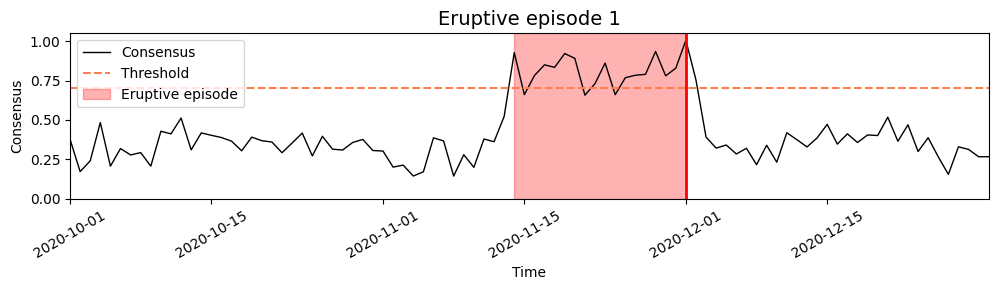

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

# Update time range according to new specifications
start_date = datetime(2020, 10, 1)   # Start of data
end_date = datetime(2020, 12, 31)    # End of data
dates = pd.date_range(start=start_date, end=end_date, freq='24h')  # Daily frequency

# Generate synthetic data similar to the image
np.random.seed(64)  # For reproducibility
n = len(dates)

# Generate consensus data with similar pattern
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise
    consensus[i] = base + 0.1 * np.sin(i/10) + 0.07 * np.random.randn()

# Find indices for eruption period
eruption_start_idx = np.where(dates >= datetime(2020, 11, 14))[0][0]
eruption_end_idx = np.where(dates >= datetime(2020, 12, 2))[0][0]  # Day after eruption ends

# Make the consensus value rise before first eruption
pre_eruption_rise_days = 3
for i in range(eruption_start_idx-pre_eruption_rise_days, eruption_start_idx):
    factor = (i - (eruption_start_idx-pre_eruption_rise_days)) / pre_eruption_rise_days
    consensus[i] = base + 0.3 * factor + 0.05 * np.random.randn()

# High values during eruption
for i in range(eruption_start_idx, eruption_end_idx):
    consensus[i] = 0.8 + 0.15 * np.random.randn()
    # Add some variability during the long eruption period
    if i - eruption_start_idx < 5:
        # Initial peak
        consensus[i] = 0.8 + 0.1 * np.random.randn()
    elif i - eruption_start_idx > (eruption_end_idx - eruption_start_idx) - 5:
        # Final peak before ending
        consensus[i] = 0.85 + 0.1 * np.random.randn()
    else:
        # Sustained but variable activity
        consensus[i] = 0.9 + 0.15 * np.sin((i - eruption_start_idx)/2) + 0.08 * np.random.randn()

# Gradual decrease after eruption for 3 days
post_eruption_days = 2
for i in range(eruption_end_idx, min(eruption_end_idx+post_eruption_days, len(consensus))):
    decay_factor = 1 - ((i - eruption_end_idx) / post_eruption_days)
    consensus[i] = max(base, 0.75 * decay_factor + 0.05 * np.random.randn())

# Set the threshold
threshold = 0.7

# Create the plot with specified figure size
plt.figure(figsize=(10, 3))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='Threshold')


# Highlight eruptive episode with updated dates
eruption_start = datetime(2020, 11, 14)
eruption_end = datetime(2020, 12, 1)
plt.axvspan(eruption_start, eruption_end, alpha=0.3, color='red', label='Eruptive episode')
plt.axvline(eruption_end, color='red', linewidth=2)

# Add annotations
eruption_duration = eruption_end - eruption_start
days_duration = eruption_duration.days
# plt.text(eruption_start + timedelta(days=days_duration/2), 0.93, f'~{days_duration} days', ha='center')
# plt.annotate('Eruptive episode 1', xy=(eruption_start + timedelta(days=8), 0.95), 
#              ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
plt.title('Eruptive episode 1', fontsize=14)

# Format the dates on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30)
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# Add a grid and legend
plt.grid(False)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

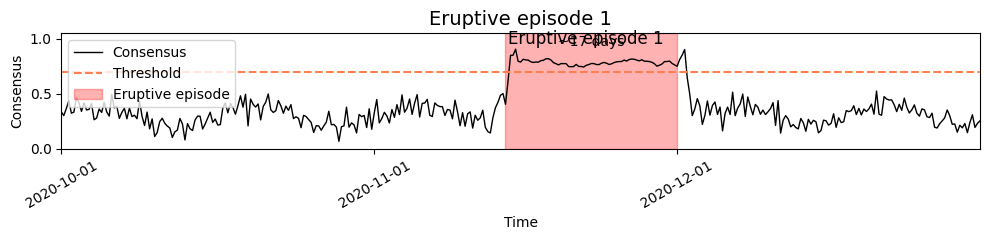

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd
from scipy.interpolate import make_interp_spline

# Update time range according to specifications
start_date = datetime(2020, 10, 1)   # Start of data
end_date = datetime(2020, 12, 31)    # End of data
dates = pd.date_range(start=start_date, end=end_date, freq='6h')  # Daily frequency

# Generate synthetic data similar to the image
np.random.seed(42)  # For reproducibility
n = len(dates)

# Generate consensus data with similar pattern
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise
    consensus[i] = base + 0.1 * np.sin(i/10) + 0.07 * np.random.randn()

# Find indices for eruption period
eruption_start_idx = np.where(dates >= datetime(2020, 11, 14))[0][0]
eruption_end_idx = np.where(dates >= datetime(2020, 12, 2))[0][0]  # Day after eruption ends

# Make the consensus value rise before first eruption
pre_eruption_rise_days = 5
for i in range(eruption_start_idx-pre_eruption_rise_days, eruption_start_idx):
    factor = (i - (eruption_start_idx-pre_eruption_rise_days)) / pre_eruption_rise_days
    consensus[i] = base + 0.3 * factor + 0.05 * np.random.randn()

# Create smoother values during eruption
eruption_days = eruption_end_idx - eruption_start_idx
eruption_pattern = np.zeros(eruption_days)

# Define key points in the eruption pattern
eruption_pattern[0:2] = [0.4, 0.60]  # Initial rise
eruption_pattern[2:5] = [0.83, 0.82, 0.89]  # First plateau
mid_point = eruption_days // 2
eruption_pattern[5:mid_point] = 0.78 + 0.03 * np.sin(np.linspace(0, 2*np.pi, mid_point-5))  # Gentle oscillation
eruption_pattern[mid_point:eruption_days-3] = 0.77 + 0.02 * np.sin(np.linspace(0, np.pi, eruption_days-mid_point-3))  # Continued activity
eruption_pattern[eruption_days-3:] = [0.82, 0.85, 0.90]  # Final burst

# Apply small smoothed random variations to make it natural
smooth_noise = np.random.randn(eruption_days)
smooth_noise = np.convolve(smooth_noise, np.ones(3)/3, mode='same')  # Smooth the noise
eruption_pattern += 0.02 * smooth_noise

# Insert the smoother eruption pattern
consensus[eruption_start_idx:eruption_end_idx] = eruption_pattern

# Gradual decrease after eruption for 3 days
post_eruption_days = 3
for i in range(eruption_end_idx, min(eruption_end_idx+post_eruption_days, len(consensus))):
    decay_factor = 1 - ((i - eruption_end_idx) / post_eruption_days)
    consensus[i] = max(base, 0.75 * decay_factor + 0.05 * np.random.randn())

# Set the threshold
threshold = 0.7

# Create the plot with specified figure size
plt.figure(figsize=(10, 2.5))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='Threshold')

# Highlight eruptive episode with updated dates
eruption_start = datetime(2020, 11, 14)
eruption_end = datetime(2020, 12, 1)
plt.axvspan(eruption_start, eruption_end, alpha=0.3, color='red', label='Eruptive episode')

# Add annotations
eruption_duration = eruption_end - eruption_start
days_duration = eruption_duration.days
plt.text(eruption_start + timedelta(days=days_duration/2), 0.93, f'~{days_duration} days', ha='center')
plt.annotate('Eruptive episode 1', xy=(eruption_start + timedelta(days=8), 0.95), 
             ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
plt.title('Eruptive episode 1', fontsize=14)

# Format the dates on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# Add a grid and legend
plt.grid(False)
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

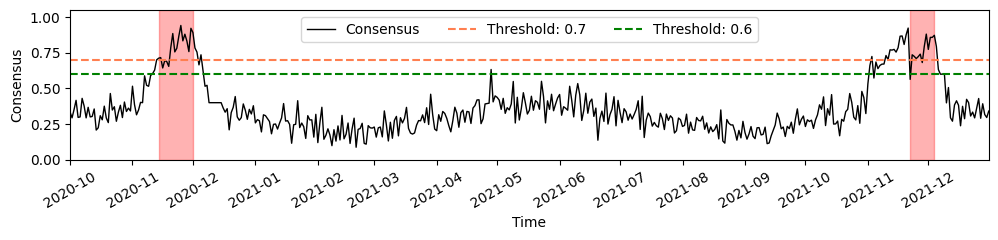

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

# Extended time range
start_date = datetime(2020, 10, 1)   # Start of data
end_date = datetime(2021, 12, 31)    # Extended end date
dates = pd.date_range(start=start_date, end=end_date, freq='24h')  # Daily frequency

# Generate synthetic data
np.random.seed(42)  # For reproducibility
n = len(dates)

# Generate baseline consensus data
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise and some long-term variations
    phase = i / 30  # Slower oscillation
    consensus[i] = base + 0.1 * np.sin(phase) + 0.07 * np.random.randn()

# Define eruption periods
eruption1_start = datetime(2020, 11, 14)
eruption1_end = datetime(2020, 12, 1)
eruption2_start = datetime(2021, 11, 22)
eruption2_end = datetime(2021, 12, 4)

# Find indices for eruption periods
eruption1_start_idx = np.where(dates >= eruption1_start)[0][0]
eruption1_end_idx = np.where(dates >= eruption1_end)[0][0] + 1  # +1 to include end date
eruption2_start_idx = np.where(dates >= eruption2_start)[0][0]
eruption2_end_idx = np.where(dates >= eruption2_end)[0][0] + 1  # +1 to include end date

# Function to model an eruption with gradual increase
def model_eruption(consensus_array, start_idx, end_idx, pre_eruption_days=5, post_eruption_days=3, base_level=0.3):
    # Pre-eruption rise
    for i in range(start_idx-pre_eruption_days, start_idx):
        if i >= 0:  # Ensure we don't go before the beginning of our data
            factor = (i - (start_idx-pre_eruption_days)) / pre_eruption_days
            consensus_array[i] = base_level + 0.3 * factor + 0.05 * np.random.randn()
    
    # Gradual increase during eruption
    eruption_duration = end_idx - start_idx
    for i in range(start_idx, end_idx):
        # Calculate progress through eruption (0 to 1)
        progress = (i - start_idx) / max(0.8, eruption_duration)
        
        # Start above threshold and gradually increase to peak
        base_value = 0.68 + 0.23 * progress
        
        # Add some variability while maintaining the upward trend
        consensus_array[i] = base_value + 0.05 * np.sin(i*2) + 0.04 * np.random.randn()
    
    # Gradual decrease after eruption
    for i in range(end_idx, min(end_idx+post_eruption_days, len(consensus_array))):
        decay_factor = 0.9 - ((i - end_idx) / post_eruption_days)
        consensus_array[i] = max(base_level, 0.95 * decay_factor + 0.05 * np.random.randn())
    
    return consensus_array

# Apply eruption models
consensus = model_eruption(consensus, eruption1_start_idx, eruption1_end_idx, base_level=0.4, pre_eruption_days=10, post_eruption_days=14)
consensus = model_eruption(consensus, eruption2_start_idx, eruption2_end_idx, base_level=0.6, pre_eruption_days=21, post_eruption_days=5)

# Set the threshold
threshold = 0.7

# Create the plot
plt.figure(figsize=(10, 2.5))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='0.7')

plt.axhline(y=0.6, color='green', linestyle='--', linewidth=1.5, label='0.6')

# Highlight first eruptive episode
plt.axvspan(eruption1_start, eruption1_end, alpha=0.3, color='red', label='Eruptive episode 1')

# Highlight second eruptive episode 
plt.axvspan(eruption2_start, eruption2_end, alpha=0.3, color='red', label='Eruptive episode 2')

# Add annotations for first eruption
eruption1_duration = eruption1_end - eruption1_start
days1_duration = eruption1_duration.days
# plt.text(eruption1_start + timedelta(days=days1_duration/2), 0.93, f'~{days1_duration} days', ha='center')
# plt.annotate('Eruptive episode 1', xy=(eruption1_start + timedelta(days=8), 0.95), 
#              ha='center', fontsize=12)

# Add annotations for second eruption
eruption2_duration = eruption2_end - eruption2_start
days2_duration = eruption2_duration.days
# plt.text(eruption2_start + timedelta(days=days2_duration/2), 0.93, f'~{days2_duration} days', ha='center')
# plt.annotate('Eruptive episode 2', xy=(eruption2_start + timedelta(days=6), 0.95), 
#              ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
# plt.title('Volcanic Activity Monitoring', fontsize=14)

# Format the dates on x-axis - show quarters for this longer time period
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# Add a grid and legend - custom legend to avoid duplicate entries
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = ["Consensus", "Threshold: 0.7", "Threshold: 0.6"]
unique_handles = [handles[0], handles[1], handles[2]]
plt.legend(unique_handles, unique_labels, loc='upper center', frameon=True, ncols=3)

plt.tight_layout()
plt.show()

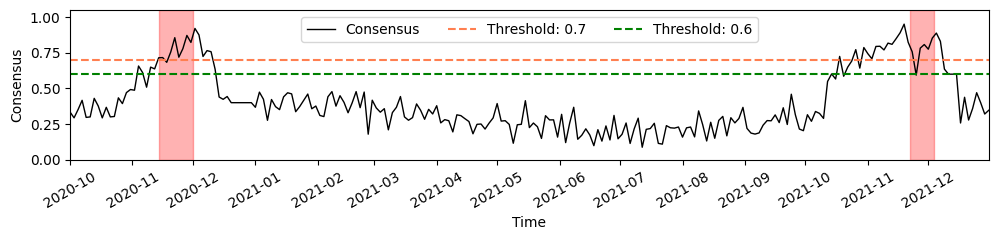

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pandas as pd

# Extended time range
start_date = datetime(2020, 10, 1)   # Start of data
end_date = datetime(2021, 12, 31)    # Extended end date
dates = pd.date_range(start=start_date, end=end_date, freq='48h')  # Daily frequency

# Generate synthetic data
np.random.seed(42)  # For reproducibility
n = len(dates)

# Generate baseline consensus data
base = 0.3
consensus = np.zeros(n)
for i in range(n):
    # Base level with noise and some long-term variations
    phase = i / 30  # Slower oscillation
    consensus[i] = base + 0.1 * np.sin(phase) + 0.07 * np.random.randn()

# Define eruption periods
eruption1_start = datetime(2020, 11, 14)
eruption1_end = datetime(2020, 12, 1)
eruption2_start = datetime(2021, 11, 22)
eruption2_end = datetime(2021, 12, 4)

# Find indices for eruption periods
eruption1_start_idx = np.where(dates >= eruption1_start)[0][0]
eruption1_end_idx = np.where(dates >= eruption1_end)[0][0] + 1  # +1 to include end date
eruption2_start_idx = np.where(dates >= eruption2_start)[0][0]
eruption2_end_idx = np.where(dates >= eruption2_end)[0][0] + 1  # +1 to include end date

# Function to model an eruption with gradual increase
def model_eruption(consensus_array, start_idx, end_idx, pre_eruption_days=5, post_eruption_days=3, base_level=0.3):
    # Pre-eruption rise
    for i in range(start_idx-pre_eruption_days, start_idx):
        if i >= 0:  # Ensure we don't go before the beginning of our data
            factor = (i - (start_idx-pre_eruption_days)) / pre_eruption_days
            consensus_array[i] = base_level + 0.3 * factor + 0.05 * np.random.randn()
    
    # Gradual increase during eruption
    eruption_duration = end_idx - start_idx
    for i in range(start_idx, end_idx):
        # Calculate progress through eruption (0 to 1)
        progress = (i - start_idx) / max(0.8, eruption_duration)
        
        # Start above threshold and gradually increase to peak
        base_value = 0.68 + 0.23 * progress
        
        # Add some variability while maintaining the upward trend
        consensus_array[i] = base_value + 0.05 * np.sin(i*2) + 0.04 * np.random.randn()
    
    # Gradual decrease after eruption
    for i in range(end_idx, min(end_idx+post_eruption_days, len(consensus_array))):
        decay_factor = 0.9 - ((i - end_idx) / post_eruption_days)
        consensus_array[i] = max(base_level, 0.95 * decay_factor + 0.05 * np.random.randn())
    
    return consensus_array

# Apply eruption models
consensus = model_eruption(consensus, eruption1_start_idx, eruption1_end_idx, base_level=0.4, pre_eruption_days=10, post_eruption_days=14)
consensus = model_eruption(consensus, eruption2_start_idx, eruption2_end_idx, base_level=0.6, pre_eruption_days=21, post_eruption_days=5)

# Set the threshold
threshold = 0.7

# Create the plot
plt.figure(figsize=(10, 2.5))

# Plot the consensus line
plt.plot(dates, consensus, color='black', linewidth=1, label='Consensus')

# Plot the threshold line
plt.axhline(y=threshold, color='#FF7F50', linestyle='--', linewidth=1.5, label='0.7')

plt.axhline(y=0.6, color='green', linestyle='--', linewidth=1.5, label='0.6')

# Highlight first eruptive episode
plt.axvspan(eruption1_start, eruption1_end, alpha=0.3, color='red', label='Eruptive episode 1')

# Highlight second eruptive episode 
plt.axvspan(eruption2_start, eruption2_end, alpha=0.3, color='red', label='Eruptive episode 2')

# Add annotations for first eruption
eruption1_duration = eruption1_end - eruption1_start
days1_duration = eruption1_duration.days
# plt.text(eruption1_start + timedelta(days=days1_duration/2), 0.93, f'~{days1_duration} days', ha='center')
# plt.annotate('Eruptive episode 1', xy=(eruption1_start + timedelta(days=8), 0.95), 
#              ha='center', fontsize=12)

# Add annotations for second eruption
eruption2_duration = eruption2_end - eruption2_start
days2_duration = eruption2_duration.days
# plt.text(eruption2_start + timedelta(days=days2_duration/2), 0.93, f'~{days2_duration} days', ha='center')
# plt.annotate('Eruptive episode 2', xy=(eruption2_start + timedelta(days=6), 0.95), 
#              ha='center', fontsize=12)

# Configure the plot
plt.ylim(0, 1.05)
plt.xlim(start_date, end_date)
plt.ylabel('Consensus')
plt.xlabel('Time')
# plt.title('Volcanic Activity Monitoring', fontsize=14)

# Format the dates on x-axis - show quarters for this longer time period
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

# Add a grid and legend - custom legend to avoid duplicate entries
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = ["Consensus", "Threshold: 0.7", "Threshold: 0.6"]
unique_handles = [handles[0], handles[1], handles[2]]
plt.legend(unique_handles, unique_labels, loc='upper center', frameon=True, ncols=3)

plt.tight_layout()
plt.show()